# Neural Network Model

Name: Karingula Hitesh

Data Used: Sentiment140 (1.6 Million Tweets)

Dataset Link: Kaggle - Twitter Sentiment Analysis https://www.kaggle.com/code/paoloripamonti/twitter-sentiment-analysis/data

In [1]:
#Using AI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text'],
    on_bad_lines='skip'
)

df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

df.dropna(subset=['text', 'sentiment'], inplace=True)

display(df)

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [3]:
df_sample = df.sample(200000, random_state=42)

display(df_sample)

,sentiment,id,date,query,user,text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem
...,...,...,...,...,...,...
1369799,1,2050886849,Fri Jun 05 19:28:21 PDT 2009,NO_QUERY,jacobdesmit,@pauseven not that pool. but i will indeed hav...
43554,0,1676557139,Fri May 01 22:24:35 PDT 2009,NO_QUERY,_free_fall_,@gerardway
559176,0,2204916250,Wed Jun 17 03:28:29 PDT 2009,NO_QUERY,FrancescaDVC,so ragin its rainin out rain rain go away
1287524,1,2002375219,Tue Jun 02 04:01:39 PDT 2009,NO_QUERY,mathaba_forum,@dwaynekerr great one


In [4]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(df_sample['text'])

y = df_sample['sentiment']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.1,
    test_size=0.02,
    random_state=20,
    stratify=y
)

In [6]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(5000,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train.toarray(),
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6879 - loss: 0.5820 - val_accuracy: 0.7337 - val_loss: 0.5219
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7943 - loss: 0.4469 - val_accuracy: 0.7335 - val_loss: 0.5401
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8425 - loss: 0.3639 - val_accuracy: 0.7232 - val_loss: 0.6049
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8861 - loss: 0.2777 - val_accuracy: 0.7207 - val_loss: 0.6976
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9250 - loss: 0.1936 - val_accuracy: 0.7143 - val_loss: 0.8494


In [9]:
predictions = (model.predict(X_test.toarray()) > 0.5).astype("int32")

print(classification_report(y_test, predictions))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.74      0.69      0.71      1997
           1       0.71      0.76      0.73      2003

    accuracy                           0.72      4000
   macro avg       0.72      0.72      0.72      4000
weighted avg       0.72      0.72      0.72      4000



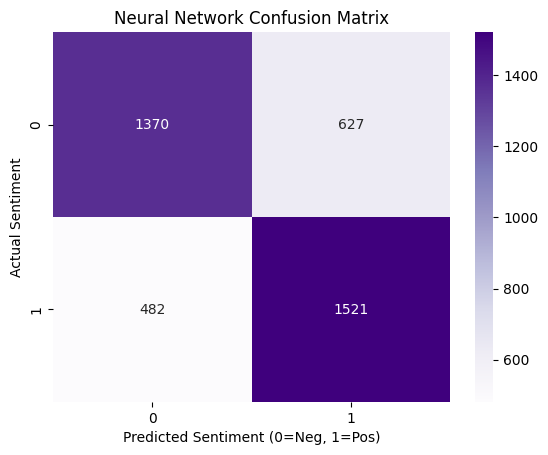

In [10]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.xlabel('Predicted Sentiment (0=Neg, 1=Pos)')
plt.ylabel('Actual Sentiment')

plt.title('Neural Network Confusion Matrix')

plt.show()

This Confusion Matrix shows that the Neural Network model performed well on the Twitter sentiment classification task by correctly identifying many positive and negative tweets. TF-IDF vectorization was used to convert the tweet text into numerical features before training the model. Dropout layers were added to help reduce overfitting during training. We considered using more advanced neural network architectures, but chose a simpler feedforward neural network because it trained faster and still produced strong accuracy on this dataset.